# Phase 3 — Product Segmentation

Assigns every product a Syntetos–Boylan demand class, an ABC volume class,
a cold-start flag, and a model-routing label.

**Routing rules (ABC-only, demand_class is a feature not a gate):**
- `category_fallback` — is_cold_start (first sale within last 12 weeks)
- `global_model`      — not cold AND abc_class ∈ {A, B}
- `baseline_intermittent` — not cold AND abc_class == C

Intermittent-demand baselines (Croston, SBA, TSB, …) are computed for **all** products
regardless of route; final per-segment model selection happens in **Phase 6** after
cross-validation metrics are compared.

Figures 13–17 are saved to `outputs/figures/` at 140 dpi.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from src.segmentation import build_segments

FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
SEG_PARQUET = ROOT / "data" / "processed" / "product_segments.parquet"

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 140,
    "figure.facecolor": "white", "axes.facecolor": "#f8f8f8",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35, "grid.color": "#cccccc",
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "legend.fontsize": 9, "legend.frameon": False,
})

# Fixed colour palette (class → colour)
DC_COLOURS = {
    "Smooth":       "#2E86AB",
    "Intermittent": "#44BBA4",
    "Erratic":      "#F18F01",
    "Lumpy":        "#C73E1D",
    "Too sparse":   "#999999",
}
ABC_COLOURS = {"A": "#2E86AB", "B": "#F18F01", "C": "#C73E1D"}
ROUTE_COLOURS = {
    "global_model":           "#2E86AB",
    "baseline_intermittent":  "#F18F01",
    "category_fallback":      "#999999",
}

def savefig(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight", dpi=140)
    print(f"Saved -> {name}")


In [2]:
# Build / reload segments
if not SEG_PARQUET.exists():
    print("Running build_segments() ...")
    seg = build_segments(parquet_out=SEG_PARQUET)
else:
    seg = pd.read_parquet(SEG_PARQUET)
    seg["first_sale_week"] = pd.to_datetime(seg["first_sale_week"])

print(f"Segments loaded: {len(seg):,} products")
print(seg.dtypes)


Segments loaded: 13,707 products
ProductID                        object
total_qty                       float32
n_active_weeks                    int32
panel_weeks                       int64
adi                             float64
cv2                             float32
first_sale_week          datetime64[ns]
weeks_since_last_sale             Int64
demand_class                     object
abc_class                        object
is_cold_start                      bool
route                            object
dtype: object


In [3]:
total_vol = seg["total_qty"].sum()

def _summary(groupby_col):
    g = (
        seg.groupby(groupby_col)
        .agg(n_products=("ProductID", "count"), total_qty=("total_qty", "sum"))
        .assign(vol_pct=lambda d: d["total_qty"] / total_vol * 100)
        .rename(columns={"total_qty": "volume"})
        .sort_values("volume", ascending=False)
    )
    return g

SEP = "=" * 65
print(SEP)
print("PHASE 3 SEGMENTATION SUMMARY")
print(SEP)

for label, col in [
    ("By demand_class (Syntetos-Boylan, ADI=1.32 / CV²=0.49)", "demand_class"),
    ("By abc_class (cumulative qty share)", "abc_class"),
    ("By route", "route"),
]:
    tbl = _summary(col)
    print(f"\n{label}")
    print(f"  {'Category':<22} {'Products':>9} {'Volume':>12} {'Vol %':>7}")
    print(f"  {'-'*22} {'-'*9} {'-'*12} {'-'*7}")
    for idx, row in tbl.iterrows():
        print(f"  {str(idx):<22} {row['n_products']:>9,} {row['volume']:>12,.0f} {row['vol_pct']:>6.1f}%")

print(f"\n  Cold-start products (first_sale within last 12 wks): {seg['is_cold_start'].sum():,}")
print(SEP)

# Routing note: intermittent baselines are computed for ALL products;
# demand_class is kept as a model feature. Final per-segment model
# selection (global LightGBM vs. baseline) happens in Phase 6.
print("\nNote: demand_class does NOT gate routing — it is a model feature.")
print("      Baselines are computed for ALL products; Phase 6 selects the")
print("      best model per segment after cross-validation.")


PHASE 3 SEGMENTATION SUMMARY

By demand_class (Syntetos-Boylan, ADI=1.32 / CV²=0.49)
  Category                Products       Volume   Vol %
  ---------------------- --------- ------------ -------
  Intermittent             5,893.0    9,975,802   72.1%
  Lumpy                    1,502.0    3,495,499   25.3%
  Too sparse               6,204.0      279,398    2.0%
  Smooth                      65.0       79,198    0.6%
  Erratic                     43.0        7,087    0.1%

By abc_class (cumulative qty share)
  Category                Products       Volume   Vol %
  ---------------------- --------- ------------ -------
  A                          677.0   11,067,977   80.0%
  B                        1,999.0    2,077,069   15.0%
  C                       11,031.0      691,938    5.0%

By route
  Category                Products       Volume   Vol %
  ---------------------- --------- ------------ -------
  global_model             2,644.0   13,104,301   94.7%
  baseline_intermittent   10

Saved -> 13_adi_cv2_scatter.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_1199/1390870998.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


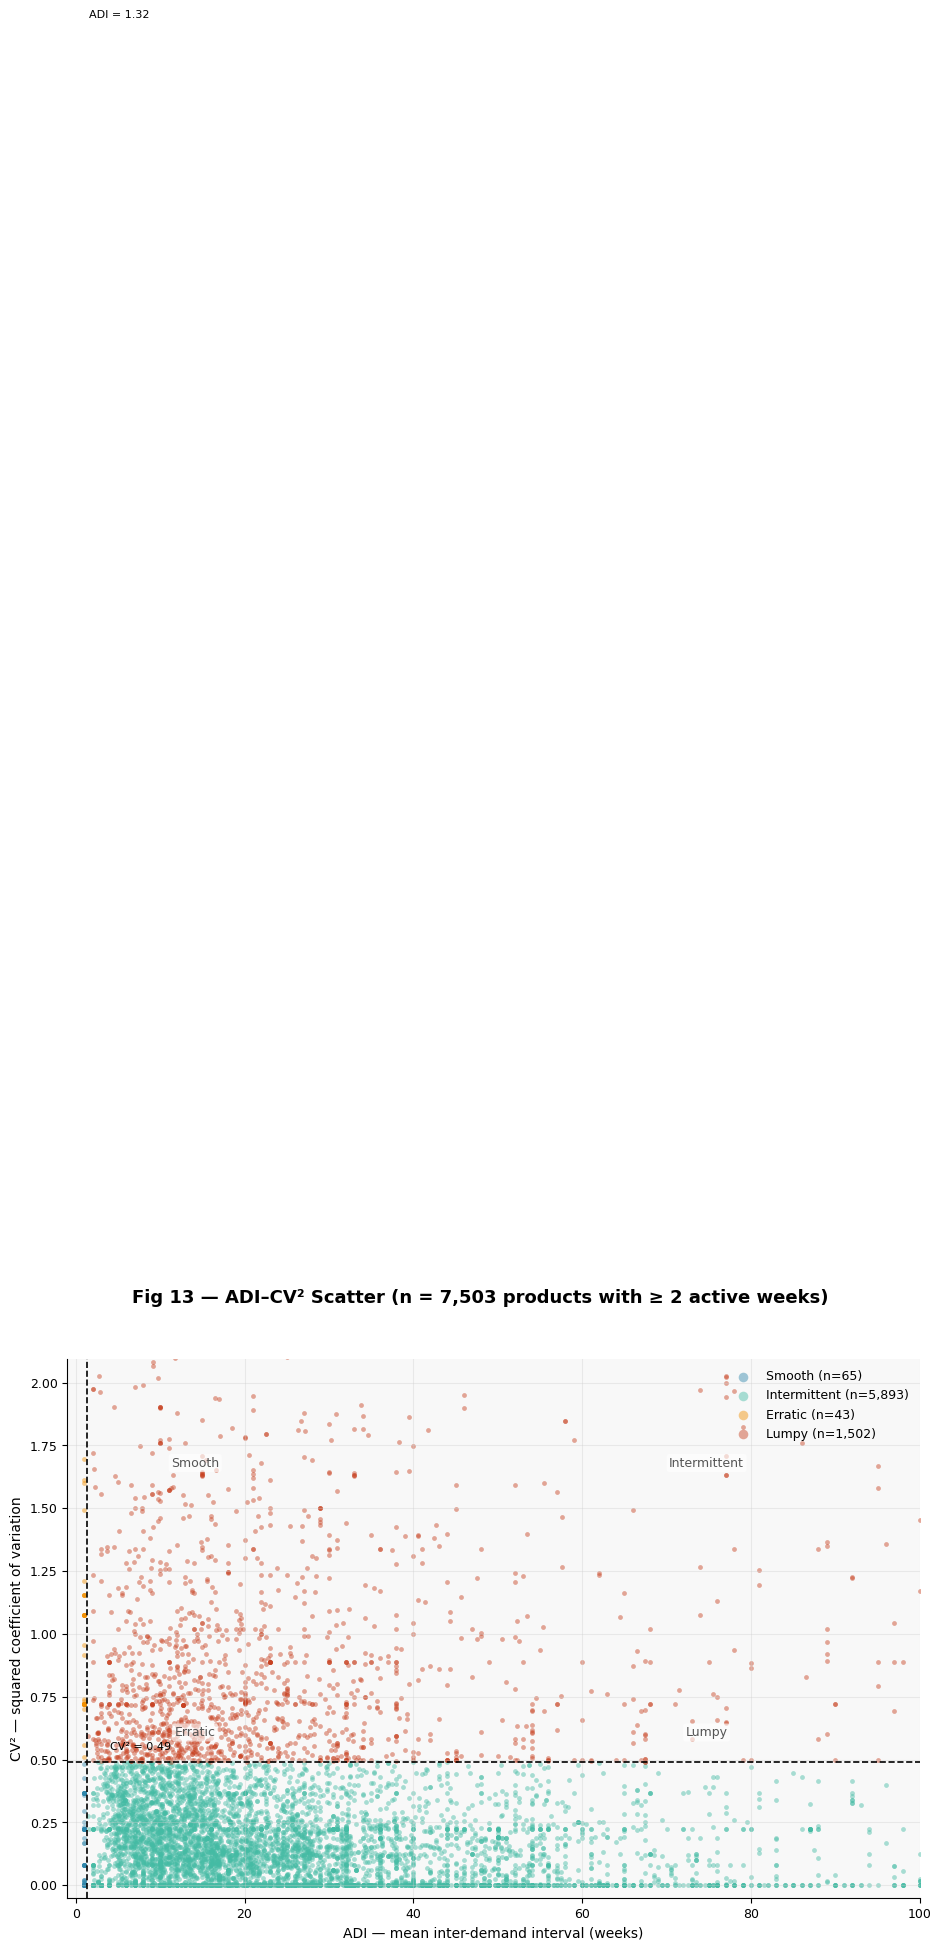

In [4]:
# ── Fig 13 — ADI–CV² scatter coloured by demand class ────────────────────────
# Only products with n_active >= 2 (ADI and CV² are defined)
scatter_df = seg[seg["n_active_weeks"] >= 2].copy()

fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle(
    f"Fig 13 — ADI–CV² Scatter (n = {len(scatter_df):,} products with ≥ 2 active weeks)",
    fontsize=13, fontweight="bold",
)

for cls, colour in DC_COLOURS.items():
    sub = scatter_df[scatter_df["demand_class"] == cls]
    if len(sub):
        ax.scatter(sub["adi"], sub["cv2"], c=colour, s=12, alpha=0.45,
                   linewidths=0, label=f"{cls} (n={len(sub):,})")

# Threshold lines
ax.axvline(_adi := 1.32, color="black", ls="--", lw=1.2, zorder=5)
ax.axhline(_cv2 := 0.49, color="black", ls="--", lw=1.2, zorder=5)
ax.text(_adi + 0.3, ax.get_ylim()[1] * 0.97, f"ADI = {_adi}", fontsize=8, va="top")
ax.text(0.05, _cv2 + 0.05, f"CV² = {_cv2}", fontsize=8, transform=ax.get_yaxis_transform())

# Quadrant labels (placed in data coordinates)
y_top = scatter_df["cv2"].quantile(0.99)
ax.set_ylim(-0.05, min(y_top * 1.1, 8))
ax.set_xlim(-1, min(scatter_df["adi"].quantile(0.99) * 1.1, 100))
for (x_frac, y_frac, label) in [
    (0.15, 0.80, "Smooth"), (0.75, 0.80, "Intermittent"),
    (0.15, 0.30, "Erratic"), (0.75, 0.30, "Lumpy"),
]:
    ax.text(x_frac, y_frac, label, transform=ax.transAxes,
            fontsize=9, color="#555555", ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

ax.set_xlabel("ADI — mean inter-demand interval (weeks)")
ax.set_ylabel("CV² — squared coefficient of variation")
ax.legend(loc="upper right", markerscale=2)

plt.tight_layout()
savefig(fig, "13_adi_cv2_scatter.png")
plt.show()

from src.segmentation import _ADI_THRESH, _CV2_THRESH
_adi = _ADI_THRESH
_cv2 = _CV2_THRESH


Saved -> 14_abc_pareto.png


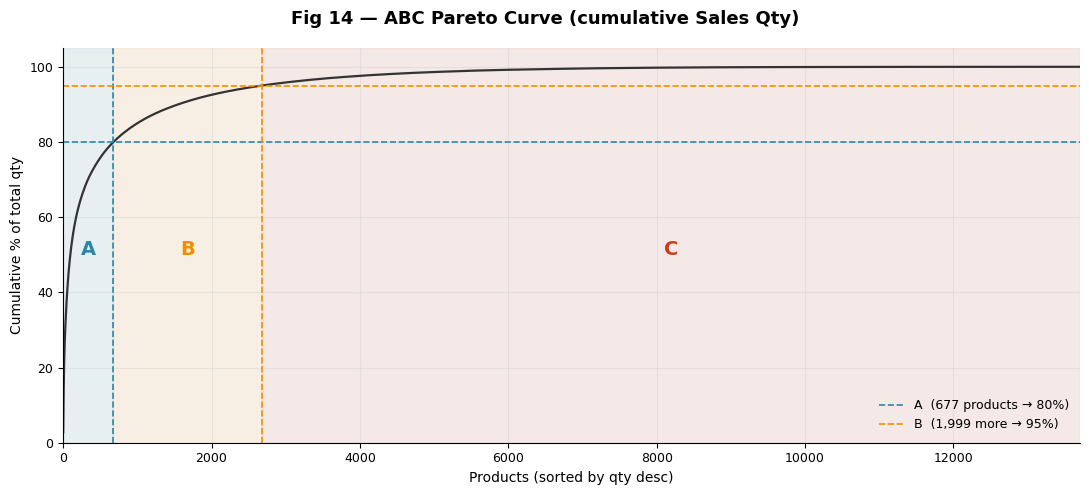

In [5]:
# ── Fig 14 — ABC Pareto curve with A / B / C cut-points ─────────────────────
prod_sort = seg.sort_values("total_qty", ascending=False).reset_index(drop=True)
cum_frac  = prod_sort["total_qty"].cumsum() / total_vol
x = np.arange(1, len(prod_sort) + 1)

n_A = (prod_sort["abc_class"] == "A").sum()
n_B = (prod_sort["abc_class"] == "B").sum()
n_C = (prod_sort["abc_class"] == "C").sum()

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Fig 14 — ABC Pareto Curve (cumulative Sales Qty)", fontsize=13, fontweight="bold")

# Shade ABC regions
ax.axvspan(0,        n_A,       alpha=0.08, color=ABC_COLOURS["A"], zorder=0)
ax.axvspan(n_A,      n_A+n_B,   alpha=0.08, color=ABC_COLOURS["B"], zorder=0)
ax.axvspan(n_A+n_B,  len(x),    alpha=0.08, color=ABC_COLOURS["C"], zorder=0)

ax.plot(x, cum_frac.values * 100, color="#333333", lw=1.6)

for n_prods, thr, col, lbl in [
    (n_A,      80, ABC_COLOURS["A"], f"A  ({n_A:,} products → 80%)"),
    (n_A+n_B,  95, ABC_COLOURS["B"], f"B  ({n_B:,} more → 95%)"),
]:
    ax.axvline(n_prods, ls="--", lw=1.2, color=col)
    ax.axhline(thr,     ls="--", lw=1.2, color=col, label=lbl)

ax.text(n_A / 2,            50, "A", ha="center", fontsize=14, color=ABC_COLOURS["A"], fontweight="bold")
ax.text(n_A + n_B / 2,      50, "B", ha="center", fontsize=14, color=ABC_COLOURS["B"], fontweight="bold")
ax.text(n_A + n_B + n_C/2,  50, "C", ha="center", fontsize=14, color=ABC_COLOURS["C"], fontweight="bold")

ax.set_xlabel("Products (sorted by qty desc)")
ax.set_ylabel("Cumulative % of total qty")
ax.set_xlim(0, len(x))
ax.set_ylim(0, 105)
ax.legend(loc="lower right")

plt.tight_layout()
savefig(fig, "14_abc_pareto.png")
plt.show()


Saved -> 15_demand_class_counts.png


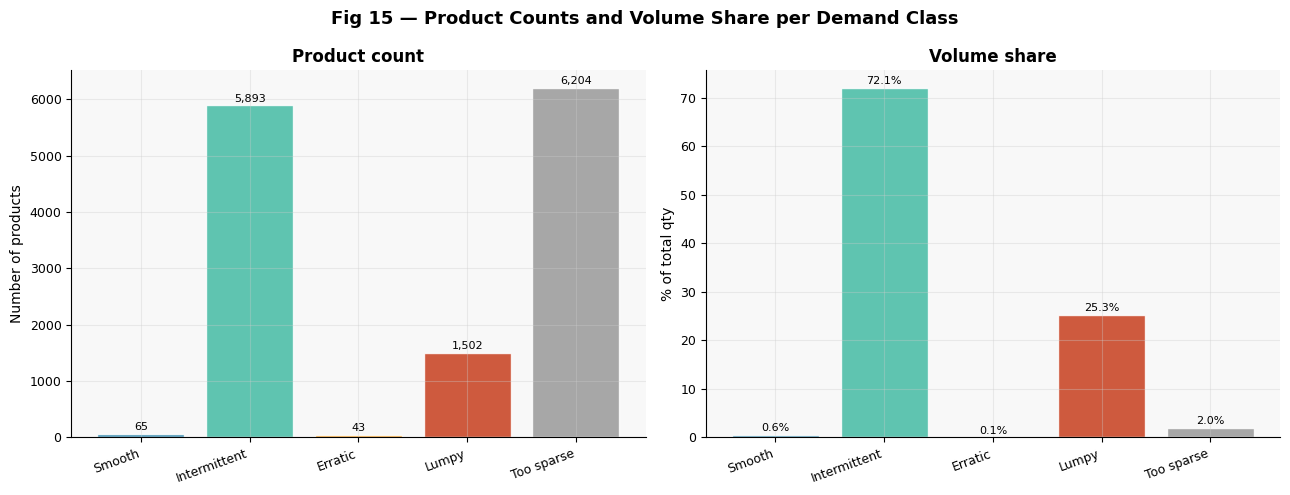

In [6]:
# ── Fig 15 — Product counts per demand class ─────────────────────────────────
dc_order = ["Smooth", "Intermittent", "Erratic", "Lumpy", "Too sparse"]
dc_counts = seg["demand_class"].value_counts().reindex(dc_order)
dc_vols   = seg.groupby("demand_class")["total_qty"].sum().reindex(dc_order)
dc_vol_pct = dc_vols / total_vol * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fig 15 — Product Counts and Volume Share per Demand Class",
             fontsize=13, fontweight="bold")

colours = [DC_COLOURS[c] for c in dc_order]

# Left: product counts
ax = axes[0]
bars = ax.bar(dc_order, dc_counts.values, color=colours, alpha=0.85, edgecolor="white")
ax.set_ylabel("Number of products")
ax.set_title("Product count")
for bar, val in zip(bars, dc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha="right")

# Right: volume share
ax2 = axes[1]
bars2 = ax2.bar(dc_order, dc_vol_pct.values, color=colours, alpha=0.85, edgecolor="white")
ax2.set_ylabel("% of total qty")
ax2.set_title("Volume share")
for bar, val in zip(bars2, dc_vol_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha="right")

plt.tight_layout()
savefig(fig, "15_demand_class_counts.png")
plt.show()


Saved -> 16_route_distribution.png


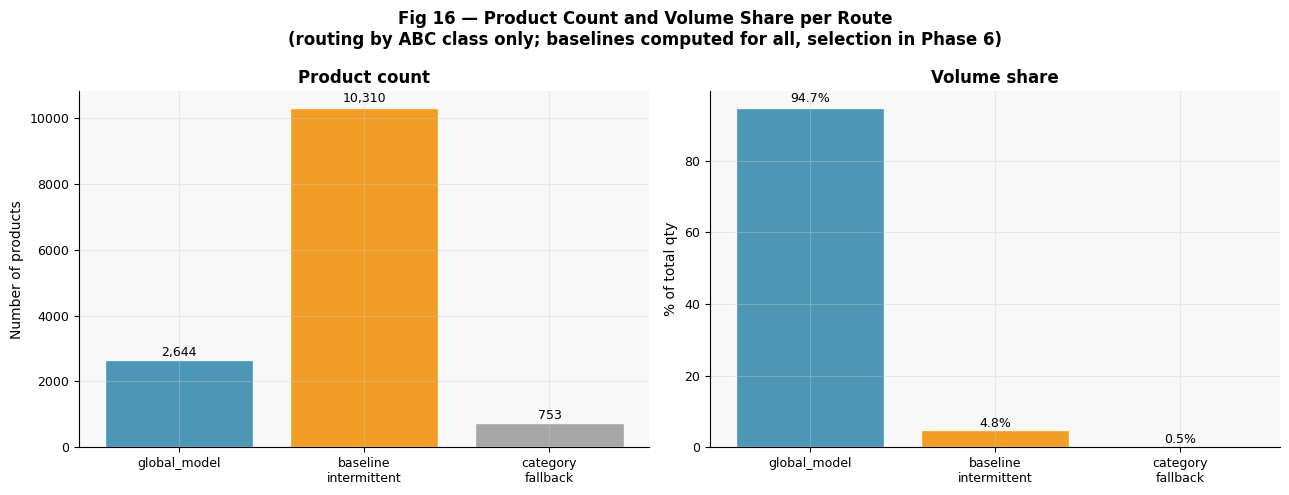

In [7]:
# ── Fig 16 — Product counts and volume share per route ───────────────────────
route_order = ["global_model", "baseline_intermittent", "category_fallback"]
route_labels = ["global_model", "baseline\nintermittent", "category\nfallback"]

r_counts  = seg["route"].value_counts().reindex(route_order)
r_vols    = seg.groupby("route")["total_qty"].sum().reindex(route_order)
r_vol_pct = r_vols / total_vol * 100

colours_r = [ROUTE_COLOURS[r] for r in route_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Fig 16 — Product Count and Volume Share per Route\n"
    "(routing by ABC class only; baselines computed for all, selection in Phase 6)",
    fontsize=12, fontweight="bold",
)

for ax, vals, ylabel, fmt in [
    (axes[0], r_counts.values,  "Number of products", "{:,}"),
    (axes[1], r_vol_pct.values, "% of total qty",     "{:.1f}%"),
]:
    bars = ax.bar(route_labels, vals, color=colours_r, alpha=0.85, edgecolor="white")
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(val), ha="center", va="bottom", fontsize=9)

axes[0].set_title("Product count")
axes[1].set_title("Volume share")

plt.tight_layout()
savefig(fig, "16_route_distribution.png")
plt.show()


Saved -> 17_abc_demand_class_heatmap.png


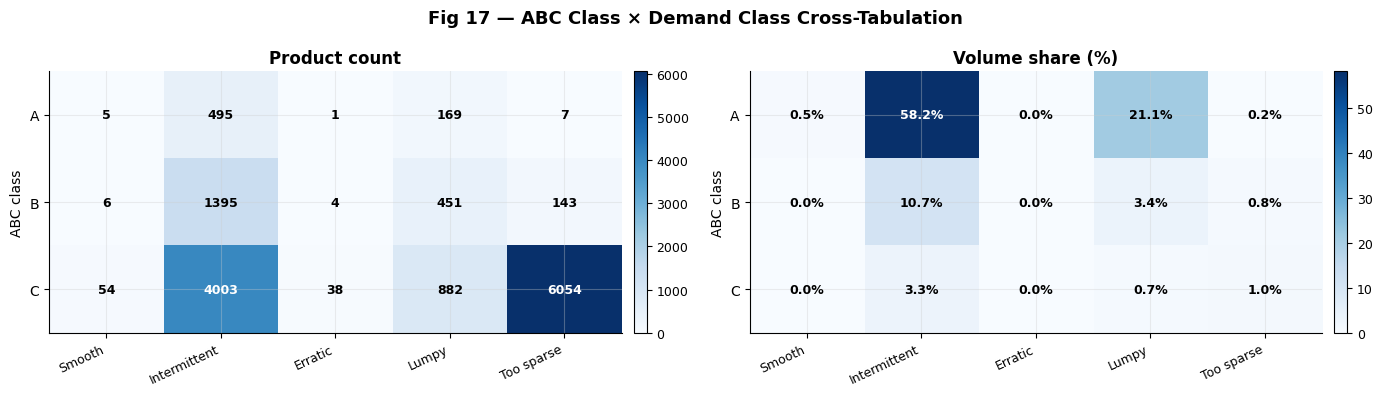

In [8]:
# ── Fig 17 — Heatmap: abc_class × demand_class ───────────────────────────────
abc_order = ["A", "B", "C"]
dc_order  = ["Smooth", "Intermittent", "Erratic", "Lumpy", "Too sparse"]

# Count crosstab
ct = pd.crosstab(seg["abc_class"], seg["demand_class"])
ct = ct.reindex(index=abc_order, columns=dc_order, fill_value=0)

# Volume crosstab
vt = seg.groupby(["abc_class","demand_class"])["total_qty"].sum().unstack(fill_value=0)
vt = vt.reindex(index=abc_order, columns=dc_order, fill_value=0)
vol_pct_mat = vt / total_vol * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Fig 17 — ABC Class × Demand Class Cross-Tabulation",
             fontsize=13, fontweight="bold")

for ax, mat, title, fmt in [
    (axes[0], ct.values.astype(float),         "Product count",    "{:.0f}"),
    (axes[1], vol_pct_mat.values.astype(float), "Volume share (%)", "{:.1f}%"),
]:
    im = ax.imshow(mat, cmap="Blues", aspect="auto",
                   vmin=0, vmax=mat.max() if mat.max() > 0 else 1)
    ax.set_xticks(range(len(dc_order)))
    ax.set_xticklabels(dc_order, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(len(abc_order)))
    ax.set_yticklabels(abc_order, fontsize=10)
    ax.set_title(title)
    ax.set_ylabel("ABC class")
    # Annotate cells
    for i in range(len(abc_order)):
        for j in range(len(dc_order)):
            val = mat[i, j]
            text_col = "white" if val > mat.max() * 0.55 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center",
                    fontsize=9, color=text_col, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
savefig(fig, "17_abc_demand_class_heatmap.png")
plt.show()


In [9]:
print("\nPhase 3 figures saved:")
for f in sorted(p for p in (ROOT / "outputs" / "figures").iterdir()
                if p.stem[:2].isdigit() and int(p.stem[:2]) >= 13):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")



Phase 3 figures saved:
  13_adi_cv2_scatter.png  (256 KB)
  14_abc_pareto.png  (61 KB)
  15_demand_class_counts.png  (61 KB)
  16_route_distribution.png  (62 KB)
  17_abc_demand_class_heatmap.png  (75 KB)
